In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib




In [ ]:
data = pd.read_excel("Prediction data.xlsx")

data.head()

<bound method NDFrame.head of      Customer_ID  Gender  ...  Churn_Category                   Churn_Reason
0      11098-MAD  Female  ...             NaN                            NaN
1      11114-PUN    Male  ...      Competitor  Competitor had better devices
2      11167-WES  Female  ...             NaN                            NaN
3      11179-MAH    Male  ...             NaN                            NaN
4      11180-TAM    Male  ...             NaN                            NaN
...          ...     ...  ...             ...                            ...
6002   99898-MAH  Female  ...             NaN                            NaN
6003   99912-WES  Female  ...             NaN                            NaN
6004   99942-KER    Male  ...        Attitude   Attitude of service provider
6005   99942-TEL  Female  ...             NaN                            NaN
6006   99962-AND  Female  ...             NaN                            NaN

[6007 rows x 32 columns]>

## Data Preprocesing

In [7]:
# drop columns that won't be used for prediction
data = data.drop(['Customer_ID','Churn_Category','Churn_Reason'],axis=1)






In [8]:
data.columns

Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status'],
      dtype='object')

In [9]:
#list of columns to be label encoded
columns_to_encode = ['Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method'

]

# endoded categorical variables except the target
label_encoders = {}
for column  in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# manually encode the target variable "Customer_Status"
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# spliting data into features and target
x = data.drop('Customer_Status',axis=1)
y = data['Customer_Status']



In [10]:
# spliting data into traning and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
x_train.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
5632,0,56,0,11,3,22,1,1,1,1,2,1,1,0,1,1,1,1,1,0,1,1,110.099998,4469.100098,0.000000,0,460.000000,4929.100098
5838,1,54,1,16,9,10,5,1,1,1,2,0,1,0,0,0,0,0,0,0,1,0,80.650002,1451.900024,0.000000,30,699.659973,2181.560059
2348,1,37,1,16,15,19,1,1,0,1,1,0,1,0,1,1,1,1,1,2,1,1,75.949997,4542.350098,0.000000,0,488.519989,5030.870117
5332,0,23,0,7,4,9,5,0,2,1,0,1,1,1,1,0,1,1,1,2,1,1,54.049999,2375.199951,47.450001,0,0.000000,2327.750000
5661,1,72,0,2,15,31,1,1,1,1,2,0,1,1,1,1,1,0,1,0,1,0,110.750000,4687.899902,0.000000,0,624.359985,5312.259766


In [12]:
# train the Random Forest model
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42 )


# train the model
rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [13]:
# Evaluating model
# make prediction
y_pred = rf_model.predict(x_test)

In [14]:
# Evaluate the Model
print("confusion_matrix:")
print(confusion_matrix(y_test,y_pred))
print("_"*20)
print("Classification Report:")
print(classification_report(y_test,y_pred))

confusion_matrix:
[[775  72]
 [130 225]]
____________________
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       847
           1       0.76      0.63      0.69       355

    accuracy                           0.83      1202
   macro avg       0.81      0.77      0.79      1202
weighted avg       0.83      0.83      0.83      1202



In [15]:
# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]


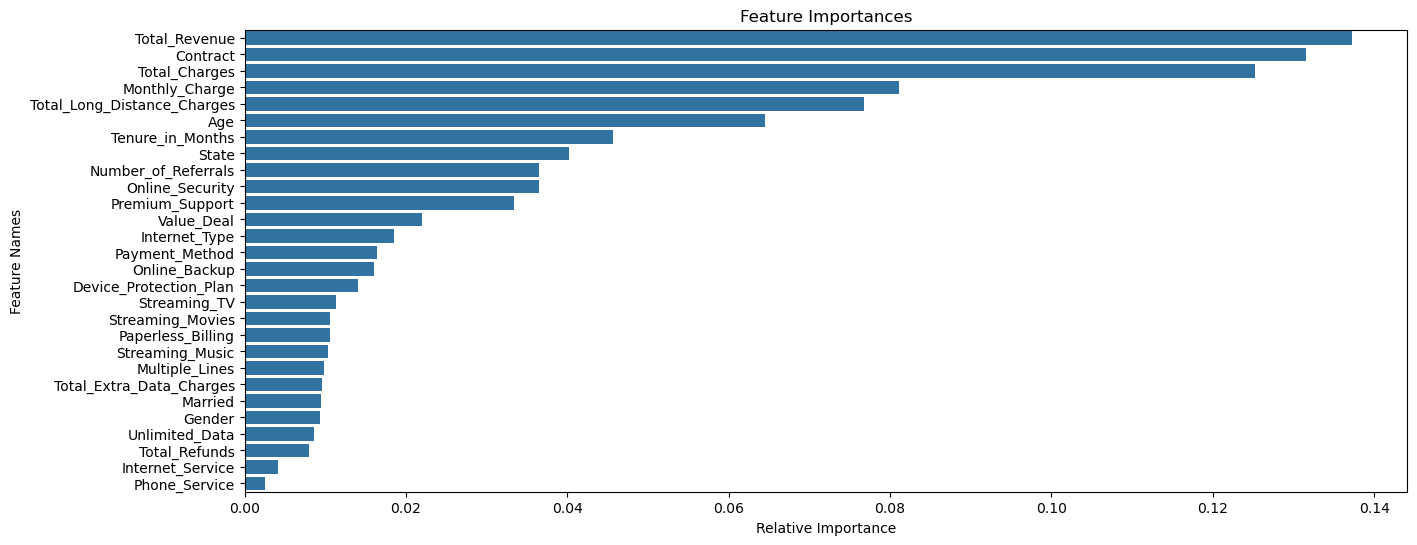

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y =x.columns[indices])
plt.title("Feature Importances")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Names")
plt.show()


In [26]:
new_data = pd.read_excel('vw_JoinsData.xlsx')

# retain the original dataframe to preserve uncoded columns
original_data = new_data.copy()

# retain the customer id column
customer_ids = new_data['Customer_ID']

# drop the columns that won't be used fot prediction in encoded DataFrame
new_data = new_data.drop(['Customer_ID','Customer_Status','Churn_Category','Churn_Reason'],axis=1)

# encode categrical variables using the saved label encoders
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])



In [27]:
# make prediction
new_predictions = rf_model.predict(new_data)


# add prediction ti the original dataframe
original_data['Customer_Status_Predicted'] = new_predictions


# fillter the dataframe to include  only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

# save the results
original_data.to_csv('Predicted_Data.csv')